In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import mat73 as mt
import scipy.io as sio
import matplotlib.pyplot as plt

from fppnpx.preprocessing import read_session, load_waveforms, read_bin
from fppnpx.ChannelSignal import ChannelSignal
from fppnpx.plottools import MATMAP
from fppnpx.filters import gen_filter

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

/opt/miniconda3/envs/wavemapspec/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# imecpath = Path('/home/mateoumaguing/Documents/MiscData/TibsCFD/TIBERIUS_CHKDLAY_DLPFC_NPIX45_063023_g0')
imecpath = "/Users/mateouma/Desktop/TIBERIUS_CHKDLAY_DLPFC_NPIX45_063023_g0"

npxsession = read_session(time_window=[100,123], imec_path=imecpath)

Loading session from /Users/mateouma/Desktop/TIBERIUS_CHKDLAY_DLPFC_NPIX45_063023_g0
Reading metadata...
Reading channel information...
383 usable channels detected. Use `channel_map` to view usable channels.
Reading cluster information from kilosort...
Session loading complete.


In [4]:
waveformpath = "/Users/mateouma/Downloads/monkey datasets/20230630_DLPFCwaveforms.mat"
waveform_dataset, waveform_means = load_waveforms(waveformpath, npxsession)

Loading waveforms...
138 clusters with good waveforms detected.


In [115]:
ch163 = ChannelSignal(163, session_dataset=npxsession, bandtype='AP', waveform_dataset=waveform_dataset, notch_filt=1, bandpass_filt=None, time_halfbandwidth_product=3, verbose=True)

Loading AP signal from channel 163...
Selecting good units...
Reading in time-series...
Notch filtering...
Computing multitapered spectrum...


(300, 5000.0)

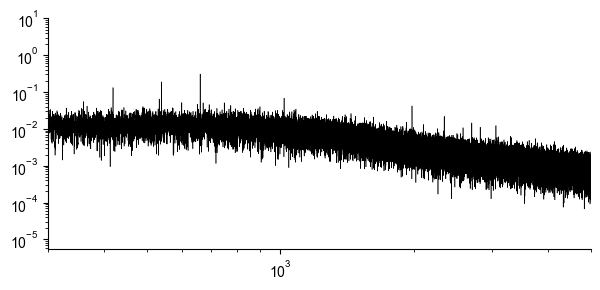

In [116]:
fig,ax = plt.subplots(figsize=(7,3))
ax.loglog(ch163.mtap_frequencies, ch163.mtap_spectrum, color='k', linewidth=0.4)
ax.set_xlim(300,5e3)

## WaveMAP

In [5]:
from fppnpx.unit_clustering import WaveMAP

In [6]:
wmc = WaveMAP()
wmc.fit(waveforms=waveform_means, verbose=True)

Computing UMAP: 15 neighbors | 0.1 minimum distance | random_state 42


/opt/miniconda3/envs/wavemapspec/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Applying Louvain method: 1.5 resolution


/opt/miniconda3/envs/wavemapspec/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


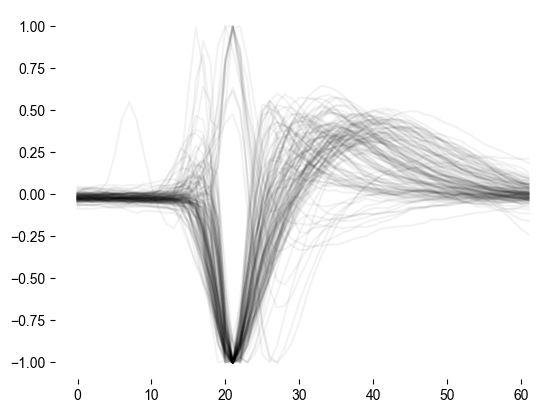

In [10]:
fig,ax = plt.subplots()
wmc.plot_waveforms(ax=ax)

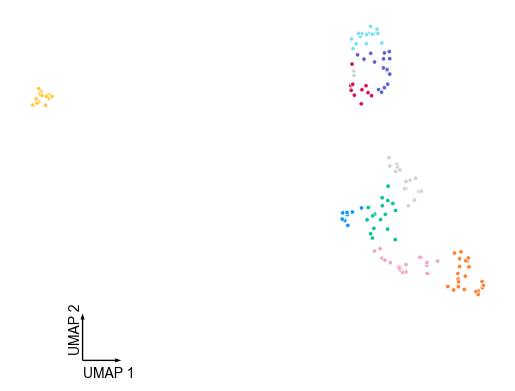

In [7]:
fig,ax = plt.subplots()
wmc.plot_umap(show_clustering_solution=True, ax=ax)

In [8]:
cluster_ids = np.array(list(waveform_dataset.keys()))
cluster_ids

array([ 17,  21,  22,  24,  35,  41,  48,  52,  64,  65,  80,  87,  91,
        95, 105, 116, 117, 123, 125, 129, 130, 135, 139, 140, 146, 150,
       153, 177, 213, 215, 227, 234, 239, 241, 247, 248, 249, 250, 251,
       255, 257, 260, 263, 265, 268, 269, 272, 274, 275, 278, 284, 286,
       287, 291, 292, 296, 298, 306, 310, 311, 313, 314, 315, 317, 322,
       323, 328, 329, 332, 333, 335, 336, 339, 340, 344, 346, 347, 348,
       350, 354, 356, 360, 362, 365, 374, 375, 378, 379, 380, 383, 389,
       392, 393, 396, 397, 398, 401, 403, 405, 410, 417, 418, 419, 423,
       429, 433, 435, 439, 441, 443, 447, 449, 469, 470, 473, 480, 491,
       496, 500, 502, 516, 519, 523, 526, 528, 530, 531, 539, 548, 552,
       554, 556, 557, 561, 572, 583, 585, 587])

In [9]:
np.array(wmc.clustering_solution)

array([0, 1, 0, 4, 3, 4, 5, 4, 4, 4, 4, 5, 7, 5, 0, 1, 3, 5, 7, 8, 0, 5,
       8, 3, 3, 8, 4, 5, 2, 4, 7, 3, 8, 7, 3, 4, 7, 8, 1, 2, 7, 3, 0, 1,
       1, 1, 3, 7, 4, 7, 4, 7, 4, 7, 8, 6, 1, 1, 1, 7, 1, 6, 3, 1, 8, 1,
       7, 2, 8, 7, 1, 8, 1, 1, 8, 5, 8, 8, 8, 1, 4, 6, 1, 0, 0, 7, 0, 6,
       6, 5, 2, 7, 4, 7, 7, 0, 0, 2, 6, 0, 7, 0, 6, 7, 0, 6, 4, 0, 5, 5,
       0, 0, 5, 2, 5, 5, 3, 8, 2, 4, 2, 4, 4, 2, 2, 4, 2, 2, 2, 4, 4, 4,
       4, 8, 8, 5, 8, 5])

In [10]:
clustering_sol_dict = {}

for i,cid in enumerate(cluster_ids):
    clustering_sol_dict[cid] = wmc.clustering_solution[i]

In [13]:
rbs_clusters = cluster_ids[np.isin(wmc.clustering_solution, [0,3,5])]
rns_clusters = cluster_ids[np.isin(wmc.clustering_solution, [1,6,7])]
ps_clusters = cluster_ids[np.isin(wmc.clustering_solution, [2])]
tbs_clusters = cluster_ids[np.isin(wmc.clustering_solution, [8])]
tns_clusters = cluster_ids[np.isin(wmc.clustering_solution, [4])]

bs_clusters = cluster_ids[np.isin(wmc.clustering_solution, [0,3,5,8])]
ns_clusters = cluster_ids[np.isin(wmc.clustering_solution, [1,4,6,7])]

rbs_clusters,rns_clusters,ps_clusters,tbs_clusters,tns_clusters

(array([ 17,  22,  35,  48,  87,  95, 105, 117, 123, 130, 135, 140, 146,
        177, 234, 247, 260, 263, 272, 315, 346, 365, 374, 378, 383, 398,
        401, 410, 418, 429, 439, 441, 443, 447, 449, 469, 473, 480, 491,
        583, 587]),
 array([ 21,  91, 116, 125, 227, 241, 249, 251, 257, 265, 268, 269, 274,
        278, 286, 291, 296, 298, 306, 310, 311, 313, 314, 317, 323, 328,
        333, 335, 339, 340, 354, 360, 362, 375, 379, 380, 392, 396, 397,
        405, 417, 419, 423, 433]),
 array([213, 255, 329, 389, 403, 470, 500, 516, 526, 528, 531, 539, 548]),
 array([129, 139, 150, 239, 250, 292, 322, 332, 336, 344, 347, 348, 350,
        496, 561, 572, 585]),
 array([ 24,  41,  52,  64,  65,  80, 153, 215, 248, 275, 284, 287, 356,
        393, 435, 502, 519, 523, 530, 552, 554, 556, 557]))

In [15]:
len(ns_clusters)

67

In [ ]:
from scipy.io import savemat

wm_cluster_labels = {'BS': bs_clusters,
                     'NS': ns_clusters}

/Users/mateouma/Documents/Research/Stephen Group/fppnpx2/fpp-npx/fppnpx/unit_clustering.py:203: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


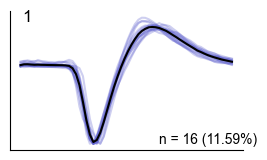

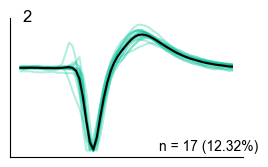

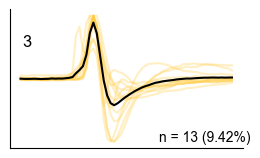

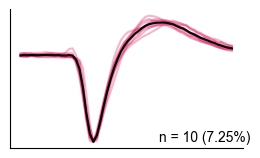

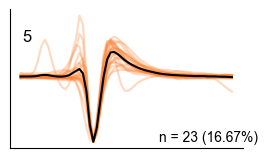

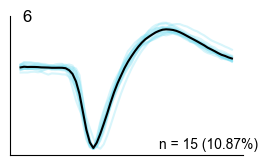

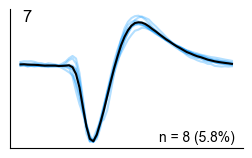

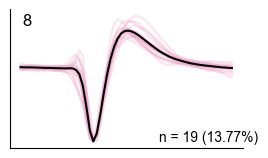

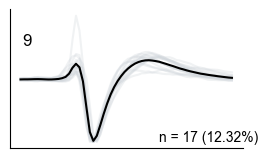

In [12]:
wmc.plot_groups()

BROAD: 0,3,5 | NARROW: 1,6,7 | POSITIVE: 2 | TRI-PHASIC: 4,8

In [16]:
cluster_filters = []

for clust in np.unique(wmc.clustering_solution):
    cluster_mean_wf = np.mean(wmc.waveforms[wmc.clustering_solution == clust], axis=0)
    cluster_filters.append(gen_filter(cluster_mean_wf, n=30000, fs=30000, center=True))

(300.0, 5000.0)

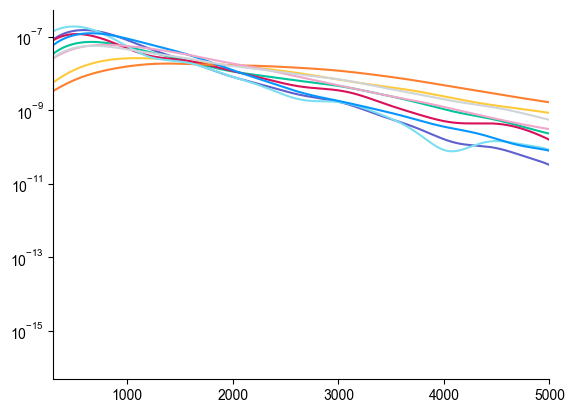

In [118]:
fig,ax = plt.subplots()
for i,clust in enumerate(np.unique(wmc.clustering_solution)):
    ax.semilogy(cluster_filters[i][3], cluster_filters[i][2], color=wmc.CLUSTER_PALETTE[i])
ax.set_xlim(300, 5000)

In [80]:
group_wm_labels = [[0,3,5], # BROAD
                   [1,6,7], # NARROW
                   [2], # POSITIVE
                   [4,8]] # TRI-PHASIC
grouped_filters = []

for i,group in enumerate(group_wm_labels):
    group_mean_wf = np.mean(wmc.waveforms[np.isin(wmc.clustering_solution, group)], axis=0)
    grouped_filters.append(gen_filter(group_mean_wf, n=30000, fs=30000, center=True))

In [82]:
clust_sol_group = {0: 'broad',
                   1: 'narrow',
                   2: 'positive',
                   3: 'broad',
                   4: 'tri-phasic',
                   5: 'broad',
                   6: 'narrow',
                   7: 'narrow',
                   8: 'tri-phasic'}

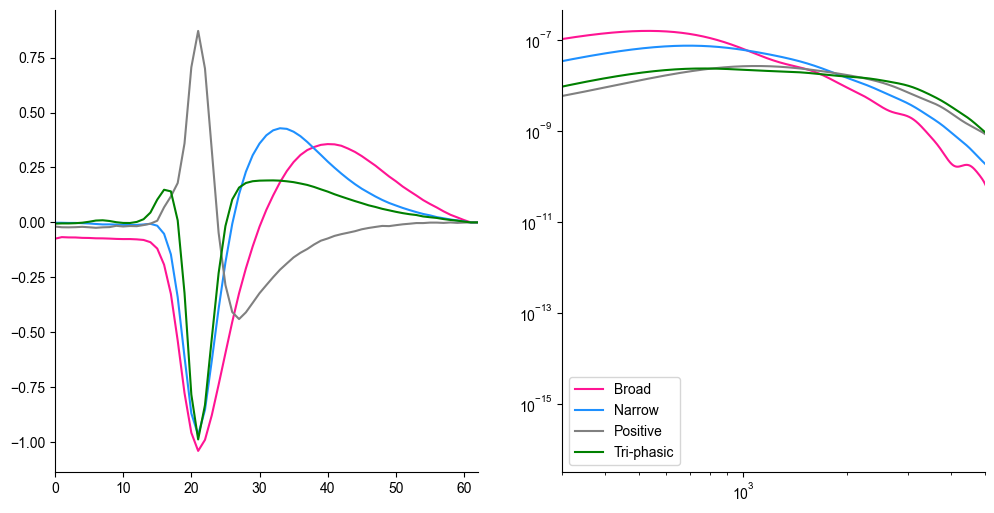

In [81]:
group_colors = ["deeppink", "dodgerblue", "gray", "green"]
group_labels = ["Broad", "Narrow", "Positive", "Tri-phasic"]

fig,ax = plt.subplots(1,2, figsize=(12,6))
for i,clust in enumerate(group_wm_labels):
    ax[0].plot(grouped_filters[i][0], color=group_colors[i])
    ax[1].loglog(grouped_filters[i][3], grouped_filters[i][2], color=group_colors[i], label=group_labels[i])
ax[0].set_xlim(0,62)
ax[1].set_xlim(300, 5000)
ax[1].legend()

In [24]:
from fppnpx.decoding import *

In [71]:
ps_clust_info = npxsession['cluster_info'][np.isin(npxsession['cluster_info']['cluster_id'], ps_clusters)] # positive-spiking cluster info
ps_clust_info

,cluster_id,Amplitude,ContamPct,KSLabel,amp,ch,depth,fr,group,n_spikes,sh
211,213,14.8,100.4,mua,34.805859,120,1220.0,0.642020,good,4478,0.0
251,255,11.3,17.4,good,38.857567,148,1500.0,1.621681,good,11311,0.0
324,329,9.2,0.6,good,31.567455,177,1780.0,5.957393,good,41552,0.0
380,389,10.2,3.3,good,38.004658,216,2180.0,0.729477,good,5088,0.0
394,403,10.2,45.7,mua,31.929825,226,2280.0,3.439781,good,23992,0.0
458,470,10.2,3.6,good,24.131901,280,2820.0,3.292538,good,22965,0.0
487,500,13.2,47.4,mua,29.688766,304,3060.0,7.787966,good,54320,0.0
503,516,16.2,1.8,good,36.545742,335,3360.0,11.411980,good,79597,0.0
512,526,10.4,1.9,good,29.176258,352,3540.0,18.291971,good,127584,0.0
514,528,13.3,110.0,mua,34.255688,357,3580.0,11.846397,good,82627,0.0


In [ ]:
npxsession['cluster_info'][np.isin(npxsession['cluster_info']['cluster_id'], ch163.detected_units)] # detected units (selected post-hoc) cluster info

,cluster_id,Amplitude,ContamPct,KSLabel,amp,ch,depth,fr,group,n_spikes,sh
282,286,16.6,4.0,good,63.869438,162,1640.0,1.838889,good,12826,0.0
283,287,9.4,11.2,good,42.383354,160,1620.0,4.351340,good,30350,0.0
287,291,17.3,49.8,mua,68.473450,160,1620.0,5.374442,good,37486,0.0
288,292,11.2,11.4,good,37.144005,160,1620.0,1.694800,good,11821,0.0
292,296,39.7,0.1,good,135.671371,163,1640.0,9.084909,good,63366,0.0
294,298,25.3,0.4,good,109.375221,166,1680.0,21.320561,good,148708,0.0


In [ ]:
depth1600s_clusters = npxsession['cluster_info'][np.logical_and(npxsession['cluster_info']['depth'] > 1600, npxsession['cluster_info']['depth'] < 1700)]
depth1600s_clusters

,cluster_id,Amplitude,ContamPct,KSLabel,amp,ch,depth,fr,group,n_spikes,sh
281,285,20.6,3.3,good,78.249512,161,1620.0,1.074573,good,7495,0.0
282,286,16.6,4.0,good,63.869438,162,1640.0,1.838889,good,12826,0.0
283,287,9.4,11.2,good,42.383354,160,1620.0,4.351340,good,30350,0.0
287,291,17.3,49.8,mua,68.473450,160,1620.0,5.374442,good,37486,0.0
288,292,11.2,11.4,good,37.144005,160,1620.0,1.694800,good,11821,0.0
290,294,16.4,267.8,mua,65.015152,164,1660.0,2.427288,good,16930,0.0
291,295,11.0,11.9,good,37.396244,163,1640.0,18.673628,good,130246,0.0
292,296,39.7,0.1,good,135.671371,163,1640.0,9.084909,good,63366,0.0
293,297,21.8,1.1,good,74.474953,165,1660.0,2.724928,good,19006,0.0
294,298,25.3,0.4,good,109.375221,166,1680.0,21.320561,good,148708,0.0


(300, 10000.0)

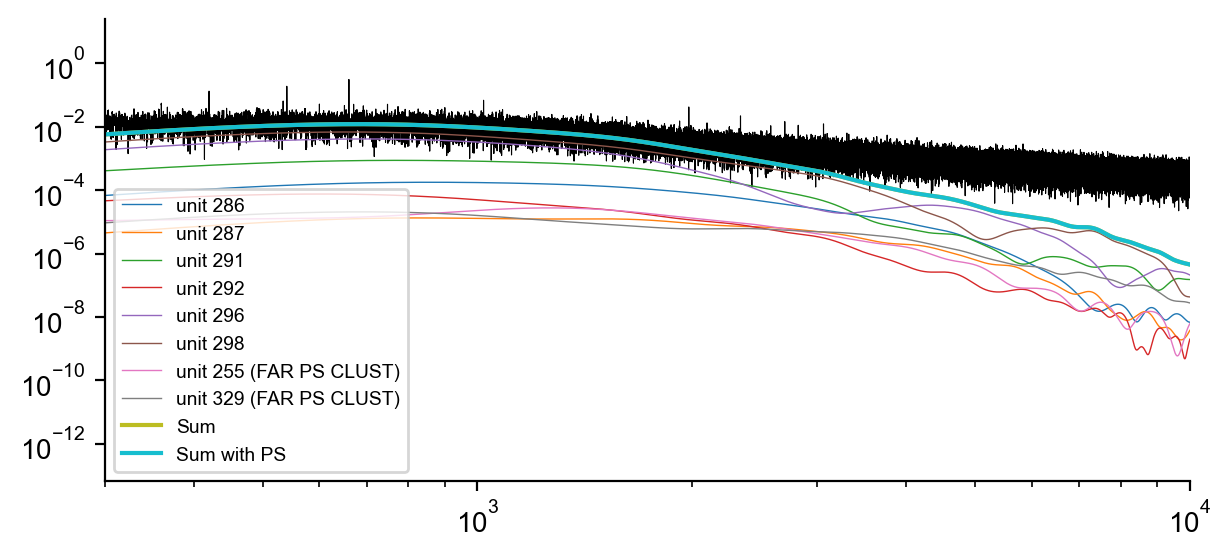

In [124]:
fig,ax = plt.subplots(figsize=(7,3), dpi=200)
ax.semilogy(ch163.mtap_frequencies, ch163.mtap_spectrum, color='k', linewidth=0.4)
# for i,clust in enumerate(group_wm_labels):
#     ax.loglog(grouped_filters[i][3], grouped_filters[i][2], color=group_colors[i], label=group_labels[i])

summed_spectra = np.zeros_like(waveform_dataset[296]['filter_spectrum'])

for i,unit in enumerate(ch163.detected_units):
    unit_spectrum = waveform_dataset[unit]['filter_spectrum'] * waveform_dataset[unit]['firing_rate']
    summed_spectra += unit_spectrum
    ax.semilogy(waveform_dataset[unit]['filter_freq_axis'], unit_spectrum, label=f"unit {unit}", linewidth=0.5)

summed_spectra_ps = summed_spectra

# add positive spiking
for unit in [255, 329]:
    unit_spectrum = waveform_dataset[unit]['filter_spectrum'] * waveform_dataset[unit]['firing_rate']
    summed_spectra_ps += unit_spectrum
    ax.semilogy(waveform_dataset[unit]['filter_freq_axis'], unit_spectrum, label=f"unit {unit} (FAR PS CLUST)", linewidth=0.5)


ax.loglog(waveform_dataset[unit]['filter_freq_axis'], summed_spectra, label='Sum')
ax.loglog(waveform_dataset[unit]['filter_freq_axis'], summed_spectra_ps, label='Sum with PS')
ax.loglog()
ax.legend(fontsize='x-small')
ax.set_xlim(300,1e4)

In [37]:
group_frs = []
unit_group_labels = []
unit_list = np.array(list(waveform_dataset.keys()))

for i,group in enumerate(group_wm_labels):
    group_mask = np.isin(wmc.clustering_solution, group)
    group_fr_list = []
    unit_group_labels.append(unit_list[group_mask])
    for unit in unit_list[group_mask]:
        group_fr_list.append(waveform_dataset[unit]['firing_rate'])
    group_frs.append(group_fr_list)

In [38]:
group_fr_sums = [np.sum(group_fr) for group_fr in group_frs]

In [39]:
unit_group_labels

[array([ 17,  22,  35,  48,  87,  95, 105, 117, 123, 130, 135, 140, 146,
        177, 234, 247, 260, 263, 272, 315, 346, 365, 374, 378, 383, 398,
        401, 410, 418, 429, 439, 441, 443, 447, 449, 469, 473, 480, 491,
        583, 587]),
 array([ 21,  91, 116, 125, 227, 241, 249, 251, 257, 265, 268, 269, 274,
        278, 286, 291, 298, 306, 310, 311, 313, 317, 323, 328, 333, 335,
        339, 340, 354, 362, 375, 392, 396, 397, 417, 423]),
 array([213, 255, 329, 389, 403, 470, 500, 516, 526, 528, 531, 539, 548]),
 array([ 24,  41,  52,  64,  65,  80, 129, 139, 150, 153, 215, 239, 248,
        250, 275, 284, 287, 292, 322, 332, 336, 344, 347, 348, 350, 356,
        393, 435, 496, 502, 519, 523, 530, 552, 554, 556, 557, 561, 572,
        585])]

(300, 10000.0)

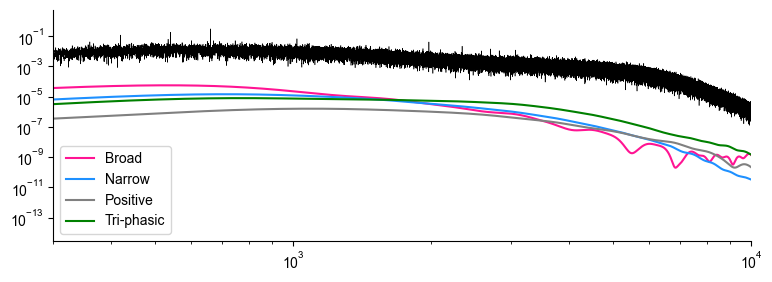

In [40]:
fig,ax = plt.subplots(figsize=(9,3))
ax.loglog(ch163.mtap_frequencies, ch163.mtap_spectrum, color='k', linewidth=0.4)
for i,clust in enumerate(group_wm_labels):
    ax.loglog(grouped_filters[i][3], grouped_filters[i][2] * group_fr_sums[i], color=group_colors[i], label=group_labels[i])
ax.loglog()
ax.legend()
ax.set_xlim(300,1e4)

Using the average waveform will not work because waveform amplitude depends on depth

In [ ]:
ch280 = ChannelSignal(280, session_dataset=npxsession, bandtype='AP', waveform_dataset=waveform_dataset, notch_filt=1, bandpass_filt=(300, 6000), time_halfbandwidth_product=3, verbose=True)
ch335 = ChannelSignal(335, session_dataset=npxsession, bandtype='AP', waveform_dataset=waveform_dataset, notch_filt=1, bandpass_filt=(300, 6000), time_halfbandwidth_product=3, verbose=True)

Loading AP signal from channel 335...
Selecting good units...
Reading in time-series...
Notch filtering...
Band-pass filtering beteen 300 and 6000 Hz...
Computing multitapered spectrum...


In [112]:
ps_clust_info

,cluster_id,Amplitude,ContamPct,KSLabel,amp,ch,depth,fr,group,n_spikes,sh
211,213,14.8,100.4,mua,34.805859,120,1220.0,0.642020,good,4478,0.0
251,255,11.3,17.4,good,38.857567,148,1500.0,1.621681,good,11311,0.0
324,329,9.2,0.6,good,31.567455,177,1780.0,5.957393,good,41552,0.0
380,389,10.2,3.3,good,38.004658,216,2180.0,0.729477,good,5088,0.0
394,403,10.2,45.7,mua,31.929825,226,2280.0,3.439781,good,23992,0.0
458,470,10.2,3.6,good,24.131901,280,2820.0,3.292538,good,22965,0.0
487,500,13.2,47.4,mua,29.688766,304,3060.0,7.787966,good,54320,0.0
503,516,16.2,1.8,good,36.545742,335,3360.0,11.411980,good,79597,0.0
512,526,10.4,1.9,good,29.176258,352,3540.0,18.291971,good,127584,0.0
514,528,13.3,110.0,mua,34.255688,357,3580.0,11.846397,good,82627,0.0


In [110]:
npxsession['clusters_on_channels'][368]

array([533, 535, 536, 537, 538, 539, 540, 541, 542, 544], dtype=int32)

In [111]:
npxsession['cluster_info'][np.isin(npxsession['cluster_info']['cluster_id'], npxsession['clusters_on_channels'][368])]

,cluster_id,Amplitude,ContamPct,KSLabel,amp,ch,depth,fr,group,n_spikes,sh
525,539,10.3,0.0,good,30.478657,368,3700.0,0.660801,good,4609,0.0


(300, 10000.0)

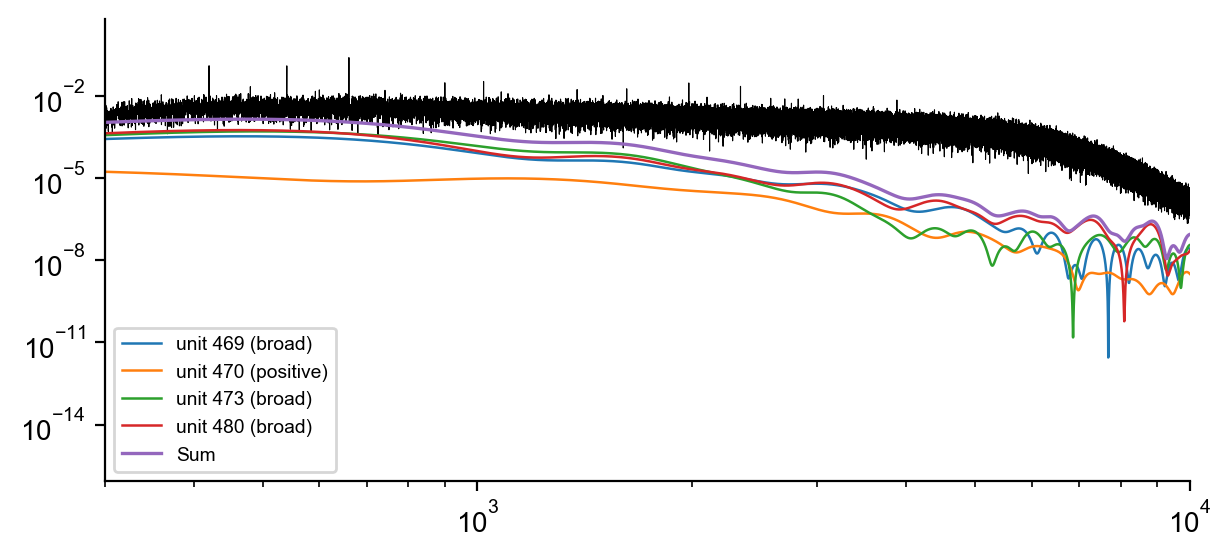

In [123]:
fig,ax = plt.subplots(figsize=(7,3), dpi=200)
ax.semilogy(ch280.mtap_frequencies, ch280.mtap_spectrum, color='k', linewidth=0.4)
# for i,clust in enumerate(group_wm_labels):
#     ax.loglog(grouped_filters[i][3], grouped_filters[i][2], color=group_colors[i], label=group_labels[i])

summed_spectra = np.zeros_like(waveform_dataset[296]['filter_spectrum'])

for i,unit in enumerate(ch280.detected_units):
    unit_spectrum = waveform_dataset[unit]['filter_spectrum'] * waveform_dataset[unit]['firing_rate']
    summed_spectra += unit_spectrum
    ax.semilogy(waveform_dataset[unit]['filter_freq_axis'], unit_spectrum, label=f"unit {unit} ({clust_sol_group[clustering_sol_dict[unit]]})", linewidth=0.9)


ax.semilogy(waveform_dataset[unit]['filter_freq_axis'], summed_spectra, label='Sum', linewidth=1.2)
# ax.loglog(waveform_dataset[unit]['filter_freq_axis'], summed_spectra_ps, label='Sum with PS')
ax.loglog()
ax.legend(fontsize='x-small')
ax.set_xlim(300,1e4)

(300, 10000.0)

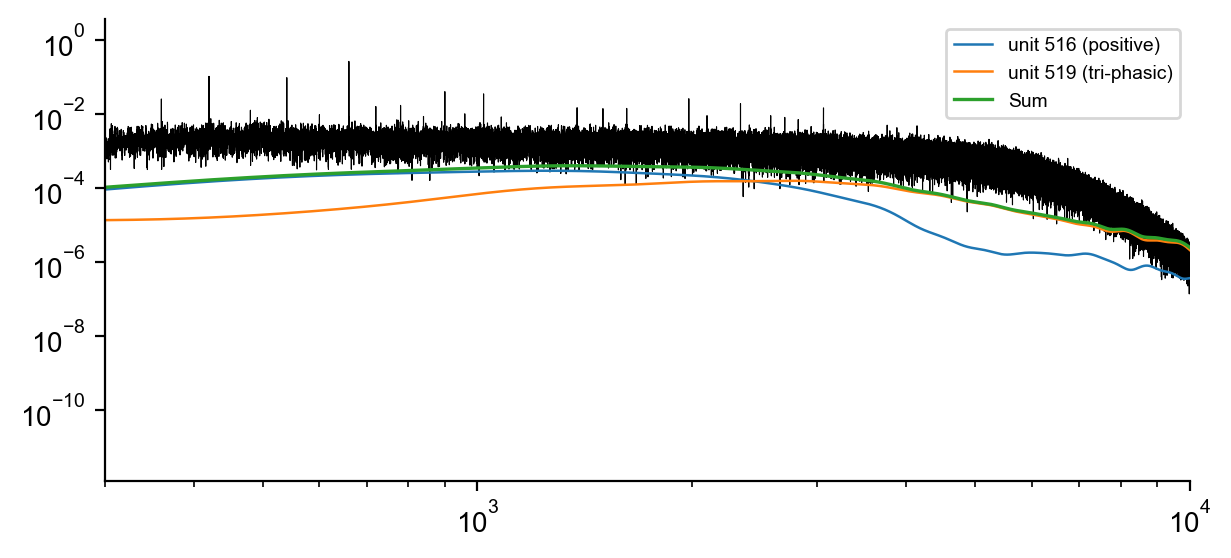

In [121]:
fig,ax = plt.subplots(figsize=(7,3), dpi=200)
ax.semilogy(ch335.mtap_frequencies, ch335.mtap_spectrum, color='k', linewidth=0.4)
# for i,clust in enumerate(group_wm_labels):
#     ax.loglog(grouped_filters[i][3], grouped_filters[i][2], color=group_colors[i], label=group_labels[i])

summed_spectra = np.zeros_like(waveform_dataset[296]['filter_spectrum'])

for i,unit in enumerate(ch335.detected_units):
    unit_spectrum = waveform_dataset[unit]['filter_spectrum'] * waveform_dataset[unit]['firing_rate']
    summed_spectra += unit_spectrum
    ax.semilogy(waveform_dataset[unit]['filter_freq_axis'], unit_spectrum, label=f"unit {unit} ({clust_sol_group[clustering_sol_dict[unit]]})", linewidth=0.9)


ax.semilogy(waveform_dataset[unit]['filter_freq_axis'], summed_spectra, label='Sum', linewidth=1.2)
# ax.loglog(waveform_dataset[unit]['filter_freq_axis'], summed_spectra_ps, label='Sum with PS')
ax.loglog()
ax.legend(fontsize='x-small')
ax.set_xlim(300,1e4)

## CORTICAL DEPTH/DISTANCE

In [42]:
npxsession['clusters_on_channels']

{0: array([0, 1, 2, 3, 4, 5, 7], dtype=int32),
 1: array([0, 1, 2, 3, 4, 5, 7], dtype=int32),
 2: array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=int32),
 3: array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=int32),
 4: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 13, 14, 15, 16],
       dtype=int32),
 5: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 13, 14, 15, 16],
       dtype=int32),
 6: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16],
       dtype=int32),
 7: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16],
       dtype=int32),
 8: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 20, 21, 22, 23], dtype=int32),
 9: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 20, 21, 22, 23], dtype=int32),
 10: array([ 6,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23],
       dtype=int32),
 11: array([ 6,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20